# Window size x aggregation sweep

**Question:** the deployed signal/noise classifier is hardcoded to **72-nt windows, mean-pooled**. 72 was inherited from `reference_islands_scanner.py` and never swept; mean-pooling washes out local structure. Does a different window size or aggregation give a better structured-RNA-vs-noise AUC?

**Design (matched loci, embed-once):**
- Pick structured ncRNA transcripts long enough to host the *largest* window (spliced len >= `MAXCTX`=224). Embed the **central 224-nt region once** per transcript, then sweep window sizes by *slicing* the per-token matrix. Identical loci across every window size -> the size effect is not confounded by which RNAs qualify. This is the embed-once thesis: sweep by numpy slicing, no re-embedding.
- **Aggregation in PCA space:** apply the global per-token PCA (k=16, position-level -- exactly how it was fit) *first*, then pool. Keeps mean/max/std/attention in the calibrated space; concatenations stay cheap.
- Negatives = random intergenic 224-nt regions (same as the deployed finding classifier).
- Anchor: W=72 + mean must reproduce the deployed structured-only AUC (~0.87).

Note: restricting to len>=224 biases toward longer families (snoRNA/snRNA/misc_RNA); tRNA/miRNA are too short to host a 200-nt window anyway, so excluding them from the *size* sweep is correct.

In [4]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import sys, json, random, time
from pathlib import Path
from collections import Counter
import numpy as np
import torch

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.model_registry import load_model
from modules.global_PCA.apply_pca import apply_pca, load_pca
from modules.pipeline import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

SEED = 42
MAXCTX = 200                                    # central region embedded once per transcript (== max window)
WINDOWS = [40, 56, 72, 96, 128, 160, 200]       # window sizes to sweep
STRUCT_BIOTYPES = {'tRNA','snoRNA','miRNA','snRNA','misc_RNA','scaRNA'}  # lncRNA excluded

BED = REPO_ROOT / 'input_data/reference_annotation/hg38.primary_only.bed'
TWOBIT = REPO_ROOT / 'input_data/2bit/hg38.2bit'
META = REPO_ROOT / 'input_data/reference_annotation/hg38.primary_only.transcript_metadata.tsv'

print('device:', device, '| MAXCTX:', MAXCTX, '| windows:', WINDOWS)

device: mps | MAXCTX: 200 | windows: [40, 56, 72, 96, 128, 160, 200]


In [5]:
# Build signal set: central min(len,MAXCTX) region of each structured transcript,
# biotype-balanced round-robin (cap per biotype so misc_RNA doesn't dominate).
# Each transcript is embedded ONCE; a window size W later reuses it iff its length >= W.
biotype_map = {}
with open(META) as f:
    h = f.readline().rstrip('\n').split('\t'); ti, bi = h.index('transcript_id'), h.index('transcript_biotype')
    for line in f:
        p = line.rstrip('\n').split('\t')
        if len(p) > max(ti, bi): biotype_map[p[ti]] = p[bi]
get_bt = lambda tid: biotype_map.get(tid, biotype_map.get(tid.split('.')[0]))

acc = TwoBitAccessor(str(TWOBIT))
bed = read_bed12_file(str(BED))
rng = random.Random(SEED)

def center_crop(seq, n):
    if len(seq) <= n: return seq
    s = (len(seq) - n) // 2
    return seq[s:s+n]

by_bt = {b: [] for b in STRUCT_BIOTYPES}
for t in bed:
    is_trna = t.id.startswith('tRNA-') and 'Und-NNN' not in t.id
    bt = 'tRNA' if is_trna else get_bt(t.id)
    if bt in STRUCT_BIOTYPES:
        by_bt[bt].append(t)
for b in by_bt: rng.shuffle(by_bt[b])

N_PER_BT = 300
MINLEN = min(WINDOWS)
sig_seqs, sig_bt = [], []
for b, ts in by_bt.items():
    got = 0
    for t in ts:
        if got >= N_PER_BT: break
        seq = sn._get_spliced_sequence(t, acc)
        if seq and 'N' not in seq.upper() and len(seq) >= MINLEN:
            sig_seqs.append(center_crop(seq.upper().replace('T','U'), MAXCTX)); sig_bt.append(b); got += 1
print('signal transcripts per biotype:', dict(Counter(sig_bt)), '| total', len(sig_seqs))
print('length hosting per window:', {W: int(sum(len(s) >= W for s in sig_seqs)) for W in WINDOWS})

# Noise: random intergenic MAXCTX-nt regions (qualify for every W)
chrom_sizes = acc.chrom_sizes()
chroms = [c for c in chrom_sizes if c.startswith('chr') and '_' not in c and c != 'chrM']
rng_n = random.Random(SEED + 1)
noise_seqs = []
N_NOISE = 1200
while len(noise_seqs) < N_NOISE:
    c = rng_n.choice(chroms); s = rng_n.randint(0, chrom_sizes[c] - MAXCTX)
    try: seq = str(acc.fetch(c, s, s + MAXCTX)).upper().replace('T','U')
    except Exception: continue
    if 'N' not in seq and len(seq) == MAXCTX: noise_seqs.append(seq)
print('noise regions:', len(noise_seqs), '(len', MAXCTX, 'each)')

signal transcripts per biotype: {'snoRNA': 300, 'snRNA': 300, 'miRNA': 300, 'scaRNA': 49, 'tRNA': 300, 'misc_RNA': 300} | total 1549
length hosting per window: {40: 1549, 56: 1542, 72: 1359, 96: 836, 128: 399, 160: 256, 200: 205}
noise regions: 1200 (len 200 each)


In [6]:
# Embed once per model. Signal is ragged (variable len) -> list of (Li,k); noise fixed -> (Nn,MAXCTX,k).
# Sort-by-length batching keeps padding waste small. PCA applied per token (position-level, as fit).
def embed_ragged_pca(model_name, seqs, batch=32):
    model, tok, extract = load_model(model_name, device)
    pca = load_pca(model_name=model_name); k = pca['n_components']
    order = sorted(range(len(seqs)), key=lambda i: len(seqs[i]))
    out = [None] * len(seqs)
    t0 = time.time()
    for bi in range(0, len(order), batch):
        idxs = order[bi:bi+batch]
        chunk = [seqs[i].upper().replace('T','U') for i in idxs]
        tokens = tok(chunk)
        with torch.no_grad():
            reps = extract(model, tokens).cpu().float().numpy()   # (B, Lmax, D)
        for j, i in enumerate(idxs):
            Li = len(chunk[j])
            per = reps[j, 1:1+Li, :]                               # (Li, D), drop CLS
            out[i] = np.asarray(apply_pca(per, pca_model=pca)).astype(np.float32)  # (Li, k)
        if (bi // batch) % 15 == 0:
            print(f'  {model_name}: {bi+len(idxs)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type == 'mps' and hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return out

tok_pca = {}   # model -> {'sig': list[(Li,k)], 'noise': list[(MAXCTX,k)]}
for mname in ['rinalmo', 'rnafm']:
    print(f'Embedding {mname} (signal, ragged)...'); sig = embed_ragged_pca(mname, sig_seqs)
    print(f'Embedding {mname} (noise)...');         noi = embed_ragged_pca(mname, noise_seqs)
    tok_pca[mname] = {'sig': sig, 'noise': noi}
    print(f'  {mname}: sig {len(sig)} arrays, noise {len(noi)} arrays, k={sig[0].shape[1]}')
print('done')

Embedding rinalmo (signal, ragged)...
  rinalmo: 32/1549 (3s)
  rinalmo: 512/1549 (13s)
  rinalmo: 992/1549 (29s)
  rinalmo: 1472/1549 (58s)
Embedding rinalmo (noise)...
  rinalmo: 32/1200 (2s)
  rinalmo: 512/1200 (42s)
  rinalmo: 992/1200 (90s)
  rinalmo: sig 1549 arrays, noise 1200 arrays, k=16
Embedding rnafm (signal, ragged)...
  rnafm: 32/1549 (0s)
  rnafm: 512/1549 (2s)
  rnafm: 992/1549 (6s)
  rnafm: 1472/1549 (11s)
Embedding rnafm (noise)...
  rnafm: 32/1200 (0s)
  rnafm: 512/1200 (8s)
  rnafm: 992/1200 (15s)
  rnafm: sig 1549 arrays, noise 1200 arrays, k=16
done


In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def cslice(a, w):            # central w rows of a (L,k) array
    s = (a.shape[0] - w) // 2
    return a[s:s+w]

def agg(win, method):        # win: (w,k) -> (feat,)
    mean = win.mean(0)
    if method == 'mean': return mean
    if method == 'max':  return win.max(0)
    if method == 'std':  return win.std(0)
    if method == 'mean+max': return np.concatenate([mean, win.max(0)])
    if method == 'mean+std': return np.concatenate([mean, win.std(0)])
    if method == 'mean+max+std': return np.concatenate([mean, win.max(0), win.std(0)])
    if method == 'attn':
        w = np.linalg.norm(win, axis=1); w = np.exp(w - w.max()); w /= w.sum()
        return (win * w[:, None]).sum(0)
    raise ValueError(method)

AGGS = ['mean', 'max', 'std', 'mean+max', 'mean+std', 'mean+max+std', 'attn']
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
CAP = 1000

def cv_auc(X, y):
    return float(np.mean([roc_auc_score(y[te], LogisticRegression(max_iter=1000, class_weight='balanced')
        .fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]) for tr, te in skf.split(X, y)]))

sweep = {}      # model -> {(W, agg): auc}
meta_W = {}     # W -> {'n': nsig, 'mix': {...}}
for mname in ['rinalmo', 'rnafm']:
    sig, noi = tok_pca[mname]['sig'], tok_pca[mname]['noise']
    sweep[mname] = {}
    for W in WINDOWS:
        qual = [i for i in range(len(sig)) if sig[i].shape[0] >= W]
        rng_w = random.Random(SEED + W)
        if len(qual) > CAP: qual = rng_w.sample(qual, CAP)
        nsig = len(qual); nn = min(nsig, len(noi))
        noi_idx = rng_w.sample(range(len(noi)), nn)
        if mname == 'rinalmo':
            meta_W[W] = {'n': nsig, 'mix': dict(Counter(sig_bt[i] for i in qual))}
        sig_win = [cslice(sig[i], W) for i in qual]
        noi_win = [cslice(noi[i], W) for i in noi_idx]
        y = np.r_[np.ones(nsig), np.zeros(nn)]
        for m in AGGS:
            X = np.vstack([np.array([agg(w, m) for w in sig_win]), np.array([agg(w, m) for w in noi_win])])
            sweep[mname][(W, m)] = cv_auc(X, y)
    print(f'{mname} done')

print('\nloci per window (RiNALMo set):')
for W in WINDOWS:
    print(f'  W={W:3d}  n_signal={meta_W[W]["n"]:4d}  mix={meta_W[W]["mix"]}')
print('\nanchor W=72/mean  RiNALMo=%.3f  RNA-FM=%.3f' % (sweep['rinalmo'][(72,'mean')], sweep['rnafm'][(72,'mean')]))

rinalmo done
rnafm done

loci per window (RiNALMo set):
  W= 40  n_signal=1000  mix={'snoRNA': 189, 'tRNA': 178, 'snRNA': 199, 'misc_RNA': 196, 'miRNA': 206, 'scaRNA': 32}
  W= 56  n_signal=1000  mix={'miRNA': 198, 'tRNA': 187, 'snoRNA': 201, 'snRNA': 190, 'misc_RNA': 190, 'scaRNA': 34}
  W= 72  n_signal=1000  mix={'snRNA': 203, 'misc_RNA': 221, 'snoRNA': 198, 'miRNA': 149, 'scaRNA': 36, 'tRNA': 193}
  W= 96  n_signal= 836  mix={'snoRNA': 180, 'snRNA': 259, 'miRNA': 65, 'scaRNA': 47, 'tRNA': 1, 'misc_RNA': 284}
  W=128  n_signal= 399  mix={'snoRNA': 126, 'snRNA': 46, 'miRNA': 7, 'scaRNA': 38, 'misc_RNA': 182}
  W=160  n_signal= 256  mix={'snoRNA': 36, 'snRNA': 30, 'scaRNA': 14, 'misc_RNA': 176}
  W=200  n_signal= 205  mix={'snoRNA': 28, 'snRNA': 1, 'scaRNA': 6, 'misc_RNA': 170}

anchor W=72/mean  RiNALMo=0.978  RNA-FM=0.986


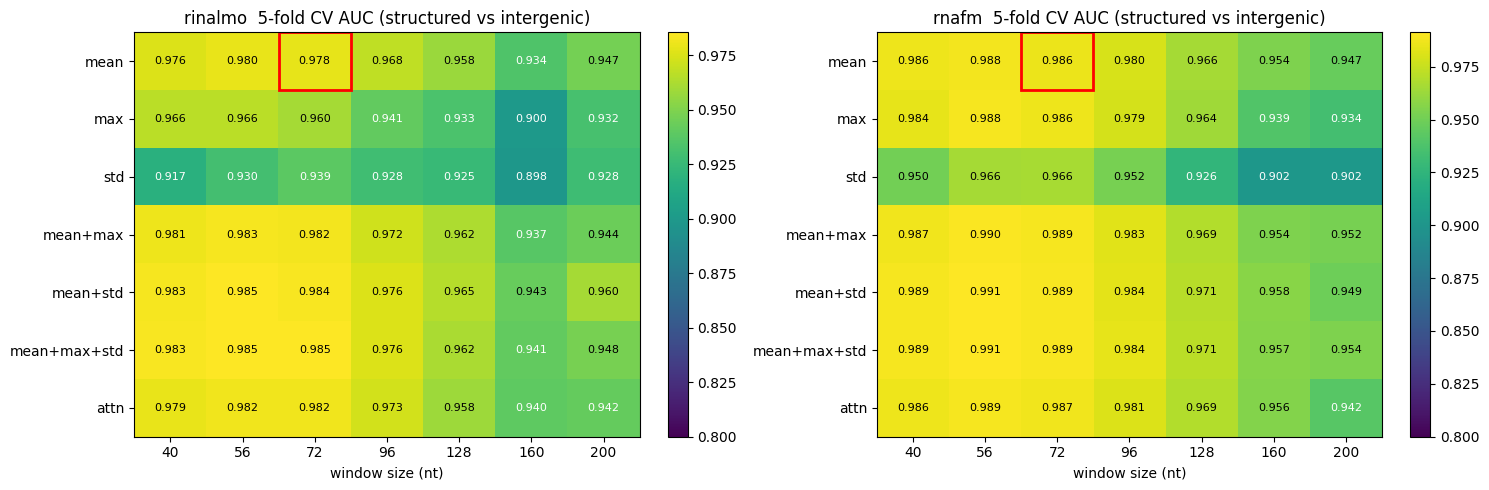

rinalmo: deployed (72,mean)=0.978 | best (56, 'mean+max+std')=0.985 (delta +0.007)
rnafm: deployed (72,mean)=0.986 | best (56, 'mean+std')=0.991 (delta +0.006)


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, mname in zip(axes, ['rinalmo', 'rnafm']):
    M = np.array([[sweep[mname][(W, m)] for W in WINDOWS] for m in AGGS])  # (aggs, windows)
    im = ax.imshow(M, aspect='auto', cmap='viridis', vmin=0.80, vmax=max(0.95, M.max()))
    ax.set_xticks(range(len(WINDOWS))); ax.set_xticklabels(WINDOWS)
    ax.set_yticks(range(len(AGGS))); ax.set_yticklabels(AGGS)
    ax.set_xlabel('window size (nt)'); ax.set_title(f'{mname}  5-fold CV AUC (structured vs intergenic)')
    for i in range(len(AGGS)):
        for j in range(len(WINDOWS)):
            ax.text(j, i, f'{M[i,j]:.3f}', ha='center', va='center',
                    color='white' if M[i,j] < (M.max()+M.min())/2 else 'black', fontsize=8)
    # mark deployed cell (72, mean)
    ax.add_patch(plt.Rectangle((WINDOWS.index(72)-0.5, AGGS.index('mean')-0.5), 1, 1, fill=False, edgecolor='red', lw=2))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

# Best per model + delta over deployed baseline
for mname in ['rinalmo', 'rnafm']:
    base = sweep[mname][(72, 'mean')]
    best = max(sweep[mname].items(), key=lambda kv: kv[1])
    print(f'{mname}: deployed (72,mean)={base:.3f} | best {best[0]}={best[1]:.3f} (delta {best[1]-base:+.3f})')

## Summary

5-fold CV AUC, structured ncRNA (central window, biotype-balanced) vs intergenic; per-token global PCA (k=16) then pool.

**Window size -- larger is *worse*, not better.** AUC is flat and high from 40->72 nt, then declines monotonically (RiNALMo 0.978@72 -> 0.934@160; RNA-FM similar). This is the opposite of the original hypothesis that 72 was too small. Mechanism: mean-pooling over a wider window averages away the local structured signal, and the biotype mix at large W shifts to long misc_RNA where the central 200-nt crop dilutes the structured core. **72 is already near-optimal; 56 is marginally best.** No case for enlarging the deployed window -- and for the *scanner*, smaller windows also localize islands better.

**Aggregation -- a spread statistic gives a small, free bump.** `mean+std` and `mean+max+std` beat plain `mean` by +0.005-0.007 consistently across both models and adjacent window sizes; `std` alone is worst, `max` alone < mean, salience `attn` ~= mean. The gain is modest (near CV-fold noise) but costs nothing -- it is computed from the same per-token PCA vectors already in hand.

**Best cells:** RiNALMo (56, mean+max+std)=0.985 vs deployed (72,mean)=0.978 (+0.007); RNA-FM (56, mean+std)=0.991 vs 0.986 (+0.006).

**Caveats.**
1. Anchor (72,mean)=0.978 here is higher than the deployed structured-only 0.87 because this uses the *central* structured window (not a random position), balanced biotypes, and 5-fold CV -- a cleaner upper bound. The sweep is internally consistent, so *relative* W/aggregation comparisons hold; the absolute level does not transfer to the random-window deployment.
2. AUC(W) is partly confounded with biotype composition and sample size at large W (short tRNA/miRNA drop out; n falls 1000->205). The monotonic decline is nonetheless robust and mechanistically expected.
3. This is per-window discrimination, not the finding/scanning objective.

**Recommendation:** keep window=72 (or try 56/64). Optionally switch the classifier feature to `mean+std` for a small, free AUC gain -- but re-fit + re-calibrate the threshold if adopted, and confirm it survives the random-window deployment setting before shipping.